In [ ]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn.metrics as metrics
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import random

import warnings
warnings.filterwarnings('ignore')

In [ ]:
import glob


glob is a Python module used to find file names that match a pattern.

In [ ]:
#unzipping dataset
!unzip /content/clothing-dataset-small.zip

Archive:  /content/clothing-dataset-small.zip
   creating: clothing-dataset-small/
  inflating: clothing-dataset-small/.DS_Store  
   creating: clothing-dataset-small/test/
   creating: clothing-dataset-small/test/skirt/
  inflating: clothing-dataset-small/test/skirt/f4b934fc-e326-4f72-b535-53288b8b82d3.jpg  
  inflating: clothing-dataset-small/test/skirt/491982c3-3e90-431e-99e6-b14ecea36384.jpg  
  inflating: clothing-dataset-small/test/skirt/24963db3-649c-4f04-8da3-0375ede8e0a6.jpg  
  inflating: clothing-dataset-small/test/skirt/32b99302-cec7-4dec-adfa-3d4029674209.jpg  
  inflating: clothing-dataset-small/test/skirt/0558b2c5-be00-49de-b27f-8c88114ac36f.jpg  
  inflating: clothing-dataset-small/test/skirt/95e66e02-b4ed-4fe9-b538-db6bac4fb7df.jpg  
  inflating: clothing-dataset-small/test/skirt/2001dec1-1e0a-4c11-9d15-120b019b3dea.jpg  
  inflating: clothing-dataset-small/test/skirt/b0e05193-cc92-4935-88d7-e71a1b19dd4b.jpg  
  inflating: clothing-dataset-small/test/skirt/309829b2-6d1

In [ ]:
os.listdir("clothing-dataset-small/train")

['pants',
 'dress',
 'outwear',
 'hat',
 'shoes',
 'skirt',
 'shorts',
 'longsleeve',
 'shirt',
 't-shirt']

In [ ]:

glob.glob(f'clothing-dataset-small/train/shirt/*')

['clothing-dataset-small/train/shirt/0999145e-6b23-4bee-8117-dbf4aaa83f1a.jpg',
 'clothing-dataset-small/train/shirt/5b62c0d7-d046-4b73-a61f-3dec701ad622.jpg',
 'clothing-dataset-small/train/shirt/93f360fb-e0fe-4052-8ab2-fe37c44dc9c1.jpg',
 'clothing-dataset-small/train/shirt/01938e19-ece6-4f67-8e48-bfd6dd6ce399.jpg',
 'clothing-dataset-small/train/shirt/363e32eb-7548-4d71-aea6-c8b6a0cbb9a2.jpg',
 'clothing-dataset-small/train/shirt/31547719-bfd1-404d-bc3f-d341489be26d.jpg',
 'clothing-dataset-small/train/shirt/adf010f4-3f9c-434f-93bb-cbfd6dddf931.jpg',
 'clothing-dataset-small/train/shirt/69504219-eb76-41d3-8ef3-9b3e1030d649.jpg',
 'clothing-dataset-small/train/shirt/378d4c2b-b181-4f51-bad6-1a04b728017f.jpg',
 'clothing-dataset-small/train/shirt/905cacba-3223-4260-9971-0de53b8f2447.jpg',
 'clothing-dataset-small/train/shirt/a934396b-3a7e-468d-bbc8-38290dd06507.jpg',
 'clothing-dataset-small/train/shirt/8839ff09-34ac-4d05-9126-57f5fc242f21.jpg',
 'clothing-dataset-small/train/shirt/4c4

In [ ]:
class_dirs=os.listdir("clothing-dataset-small/train")

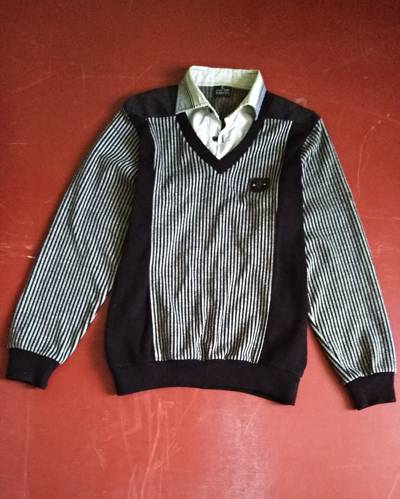

In [ ]:
# load image using keras utility function

tf.keras.utils.load_img('clothing-dataset-small/train/shirt/31547719-bfd1-404d-bc3f-d341489be26d.jpg')

In [ ]:
image_dict = {} # dict to store an image array for every class
count_dict = {} # dict to store count of files for every class

for cls in class_dirs:

    file_paths = glob.glob(f'clothing-dataset-small/train/{cls}/*')
    count_dict[cls] = len(file_paths)
    image_path = random.choice(file_paths)

    # load image using keras utility function and save it in image_dict
    image_dict[cls] = tf.keras.utils.load_img(image_path)

In [ ]:
image_dict

{'shirt': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=400x533>,
 'skirt': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=400x534>,
 'pants': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=400x533>,
 'longsleeve': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=400x533>,
 't-shirt': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=400x533>,
 'shoes': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=533x400>,
 'dress': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=400x533>,
 'hat': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=533x400>,
 'shorts': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=533x400>,
 'outwear': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=400x534>}

In [ ]:
count_dict

{'shirt': 290,
 'skirt': 112,
 'pants': 468,
 'longsleeve': 455,
 't-shirt': 795,
 'shoes': 198,
 'dress': 241,
 'hat': 123,
 'shorts': 202,
 'outwear': 184}

#### Vizualizing random sample from each class

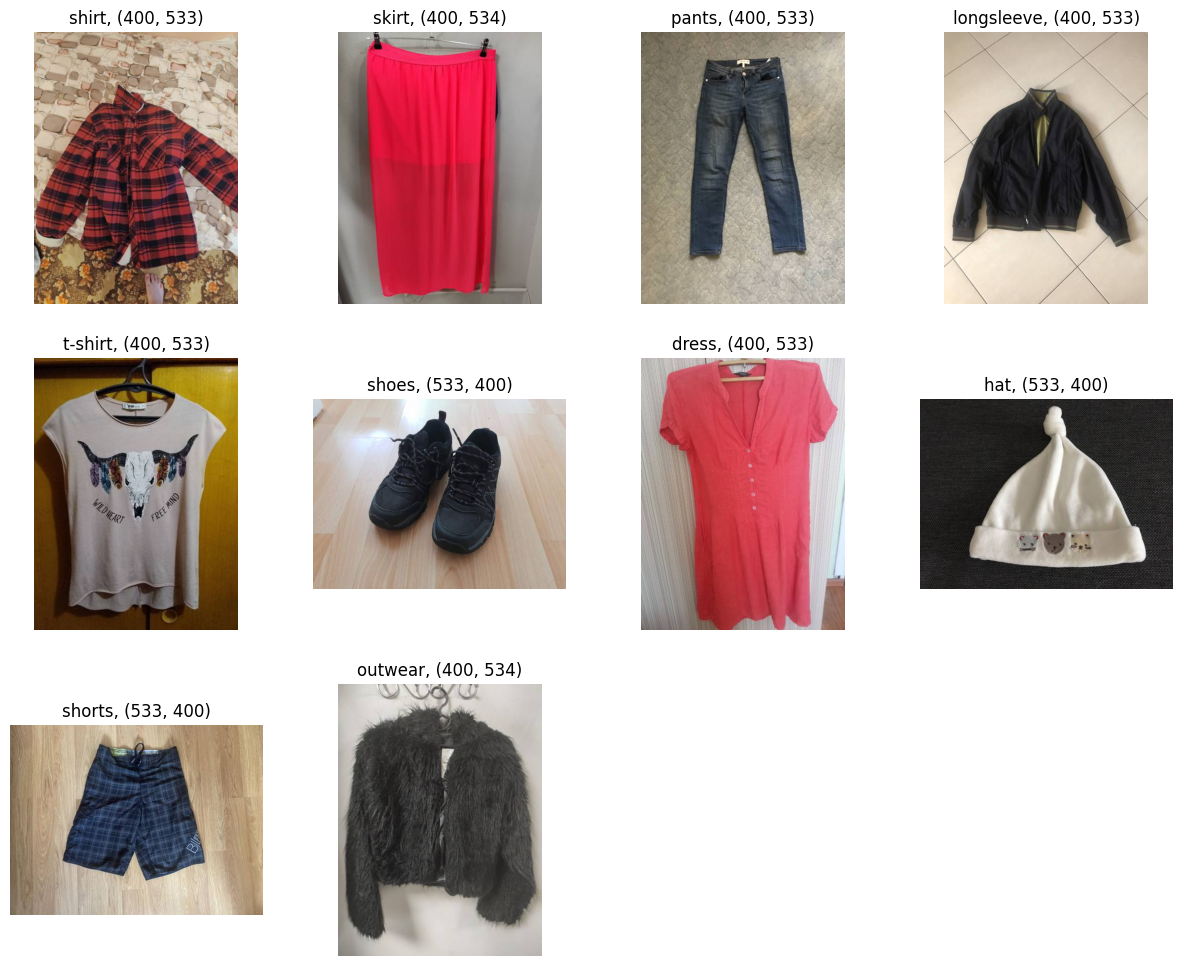

In [ ]:

plt.figure(figsize=(15, 12))

for i, (cls,img) in enumerate(image_dict.items()):
    # create a subplot axis
    ax = plt.subplot(3, 4, i + 1)            # assuming the images to be at most 12
    plt.imshow(img)
    plt.title(f'{cls}, {img.size}')
    plt.axis("off")         # remove x and y label to make the code cleaner

Here, every image has different dimension. This is expected in a real-world data, but batching requires all samples to be of the same size.

#### Visualizing the distribution of Training Data across Classes

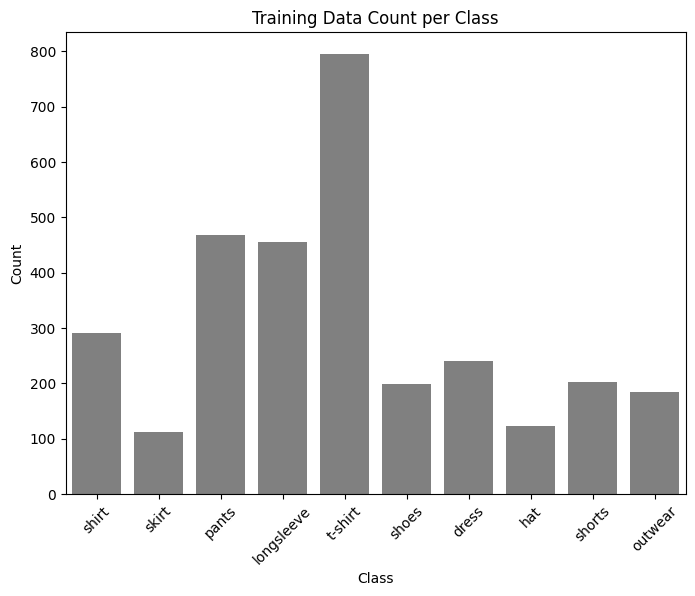

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(x=list(count_dict.keys()), y=list(count_dict.values()), color='grey')
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Training Data Count per Class")
plt.xticks(rotation=45)
plt.show()

Keras provides a utility function (tf.keras.utils.image_dataset_from_directory) to directly load data from directory in tf.data.Dataset format

In [ ]:
 tf.keras.utils.image_dataset_from_directory?

In [ ]:

print('\nLoading Train Data...')
train_data = tf.keras.utils.image_dataset_from_directory(
    "clothing-dataset-small/train", shuffle = True,
)

print('\nLoading Validation Data...')
val_data = tf.keras.utils.image_dataset_from_directory(
    "clothing-dataset-small/validation", shuffle = False,
)

print('\nLoading Test Data...')
test_data = tf.keras.utils.image_dataset_from_directory(
    "clothing-dataset-small/test", shuffle = False,
)


Loading Train Data...
Found 3068 files belonging to 10 classes.

Loading Validation Data...
Found 341 files belonging to 10 classes.

Loading Test Data...
Found 372 files belonging to 10 classes.


In [ ]:
train_data

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

every image has different dimension. This is expected in a real-world data, but batching requires all samples to be of the same size.

Neural networks require:

*   Fixed height
*   Fixed width
*   Fixed number of channels







#### Shape Preprocessing (Resizing)
- The dataset consists of images of different sizes, but a batch require images of the same size
- Resizing all the images to a fixed size (128,128)

#### Value Preprocessing (Rescaling)
- Converting the datatype of input tensor from int to float and rescaling the values to lie between 0 and 1 instead of 0 and 255
- Without scaling, the high pixel range images will have large influence on loss values and on weight updation, (ex: Black cat vs White cat)

In [ ]:
for i,j in train_data:
  print(i.shape)
  print(j.shape)

  break



(32, 256, 256, 3)
(32,)


In [ ]:
len(train_data)

96

In [ ]:
96*32

3072

In [ ]:
len(train_data)

96

#### Shape Preprocessing (Resizing)
- The dataset consists of images of different sizes, but a batch require images of the same size
- Resizing all the images to a fixed size (128,128)

#### Value Preprocessing (Rescaling)
- Converting the datatype of input tensor from int to float and rescaling the values to lie between 0 and 1 instead of 0 and 255
- Without scaling, the high pixel range images will have large influence on loss values and on weight updation, (ex: Black cat vs White cat)

In [ ]:
height, width = 128, 128       # optional value

In [ ]:
data_preprocess = keras.Sequential(
                        name="data_preprocess",
                        layers=[
                            layers.Resizing(height, width),   # Shape Preprocessing
                            layers.Rescaling(1.0/255),        # Value Preprocessing
                        ]
                  )

In [ ]:
# Perform Data Processing on the train, val, test dataset
train_ds = train_data.map(lambda x, y: (data_preprocess(x), y))
val_ds = val_data.map(lambda x, y: (data_preprocess(x), y))
test_ds = test_data.map(lambda x, y: (data_preprocess(x), y))

### **Building a Neural Network**

In [ ]:
num_classes = 10
hidden_size_1 = 1024
hidden_size_2 = 256

model = keras.Sequential(
                name="ANN_Model",
                layers=[
                    layers.Flatten(input_shape=(height, width, 3)),          # alternatively, input_shape=next(iter(train_ds))[0].shape[1:]
                    layers.Dense(units=hidden_size_1, activation='relu'),
                    layers.Dense(units=hidden_size_2, activation='relu'),
                    layers.Dense(units=num_classes, activation='softmax'),
                ]
            )

To visualize the Model Structure, run the below cell in Google Colab

In [ ]:
#tf.keras.utils.plot_model(model, to_file="ANN_Model.png", show_shapes=True)

In [ ]:
model.summary()

Model: "ANN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    50,332,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,597,642 (193.01 MB)

 Trainable params: 50,597,642 (193.01 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
epochs = 10
model_fit = model.fit(train_ds, validation_data=val_ds, epochs=epochs)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - accuracy: 0.1751 - loss: 39.6391 - val_accuracy: 0.2845 - val_loss: 3.2124
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - accuracy: 0.3336 - loss: 2.5391 - val_accuracy: 0.3372 - val_loss: 2.3865
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - accuracy: 0.4049 - loss: 1.9617 - val_accuracy: 0.4457 - val_loss: 1.7874
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.4405 - loss: 1.7484 - val_accuracy: 0.4047 - val_loss: 1.8481
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - accuracy: 0.4646 - loss: 1.6477 - val_accuracy: 0.4194 - val_loss: 1.8404
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - accuracy: 0.4675 - loss: 1.6033 - val_accuracy: 0.4663 - val_loss: 1.6804
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - accuracy: 0.5192 - loss: 1.4611 - val_accuracy: 0.4194 - val_loss: 1.7161
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.5180 - loss: 1.4628 - val_accuracy: 0.4692

#### Performance Check

In [ ]:
params = model_fit.params
params

{'verbose': 'auto', 'epochs': 10, 'steps': 96}

In [ ]:
history = model_fit.history
history

{'accuracy': [0.23631030321121216,
  0.3604954481124878,
  0.4106909930706024,
  0.45176011323928833,
  0.46773141622543335,
  0.4892438054084778,
  0.5162972807884216,
  0.5325945019721985,
  0.5202085971832275,
  0.5479139685630798],
 'loss': [18.011829376220703,
  2.3458950519561768,
  1.9342526197433472,
  1.7381606101989746,
  1.6521923542022705,
  1.551203966140747,
  1.4965225458145142,
  1.4526528120040894,
  1.4422341585159302,
  1.3635599613189697],
 'val_accuracy': [0.2844574749469757,
  0.3372434079647064,
  0.4457477927207947,
  0.4046920835971832,
  0.4193548262119293,
  0.4662756621837616,
  0.4193548262119293,
  0.4692082107067108,
  0.46041056513786316,
  0.4516128897666931],
 'val_loss': [3.2123711109161377,
  2.3864829540252686,
  1.7873796224594116,
  1.8481148481369019,
  1.8403635025024414,
  1.6804312467575073,
  1.7161414623260498,
  1.7315471172332764,
  1.6552584171295166,
  1.604339361190796]}

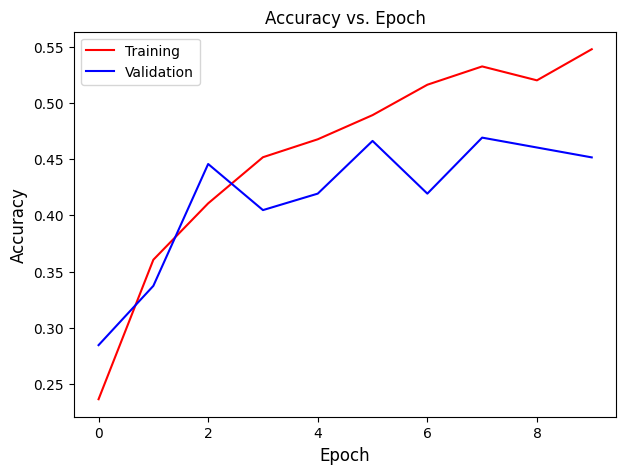

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(range(0, params['epochs']), history['accuracy'], label='Training', color='r')
plt.plot(range(0, params['epochs']), history['val_accuracy'], label='Validation', color='b')

plt.title('Accuracy vs. Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.legend()

plt.show()

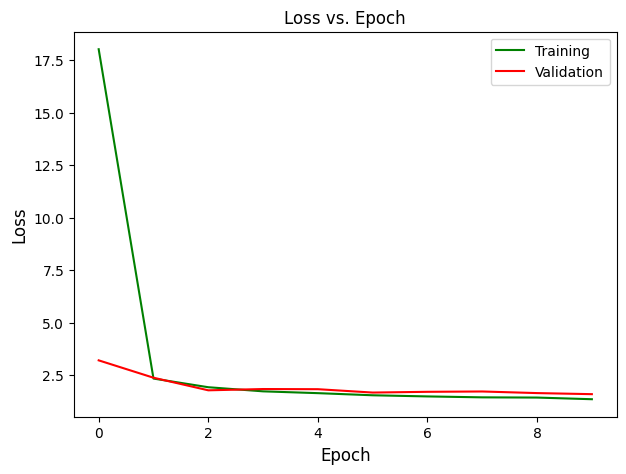

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(range(0, params['epochs']), history['loss'], label='Training', color='g')
plt.plot(range(0, params['epochs']), history['val_loss'], label='Validation', color='r')

plt.title('Loss vs. Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.legend()

plt.show()

#### Performance on Test Data

In [ ]:
y_pred = model.predict(test_ds)
y_pred

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step


array([[2.0385998e-01, 2.5295226e-02, 7.2381854e-02, ..., 1.7526846e-02,
        7.6025516e-02, 4.9048892e-01],
       [3.5698822e-01, 1.4843408e-02, 6.7334108e-02, ..., 8.6413277e-03,
        9.3362190e-02, 2.5655788e-01],
       [1.7012617e-01, 2.7972288e-02, 8.7686308e-02, ..., 3.8270120e-02,
        9.9656023e-02, 2.9109937e-01],
       ...,
       [7.1776049e-05, 1.7266497e-05, 5.0722761e-04, ..., 2.3057624e-05,
        7.4998388e-05, 9.9924594e-01],
       [5.2948222e-02, 1.0892131e-02, 4.2795565e-02, ..., 5.3171791e-02,
        6.5976754e-02, 3.6044538e-02],
       [2.8425327e-03, 5.4804649e-04, 2.9022263e-02, ..., 4.9130863e-04,
        4.4934670e-03, 9.5542014e-01]], dtype=float32)

#### Simple Neural Network shows extreme poor performance. Why??
- MLP flattens the image. It is not position invariant, hence not considering the neighbouring pixels and the Image channels (R-G-B)
- MLP doesnot consider Spatial relations. Spatial Information (like if a Person is standing at the right side of the Car or The red car is on the left side of the blue bike) gets lost when the image is flattened
- MLP is a fully connected model, it requires a neuron for every input pixel of the image. Thus, it includes many parameters

### **Convolutional Neural Network**

In [ ]:
num_classes = 10
cnn_model = keras.Sequential(
                name="CNN_Model",
                layers=[
                    layers.Conv2D(kernel_size=3 , filters=20 , strides=1 , activation="relu" , input_shape=(height, width, 3)),
                    layers.MaxPool2D(),
                    layers.Flatten(),
                    layers.Dense(250, activation='relu'),
                    layers.Dense(units=num_classes, activation='softmax'),
                ]
            )

In [ ]:
cnn_model.summary()

Model: "CNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 20)   │           560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 20)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 79380)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 250)            │    19,845,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,848,320 (75.72 MB)

 Trainable params: 19,848,320 (75.72 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn_model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
epochs = 10
model_fit = cnn_model.fit(train_ds, validation_data=val_ds, epochs=epochs)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - accuracy: 0.2250 - loss: 5.5560 - val_accuracy: 0.4076 - val_loss: 1.8286
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - accuracy: 0.4961 - loss: 1.5844 - val_accuracy: 0.4633 - val_loss: 1.5833
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.6062 - loss: 1.1981 - val_accuracy: 0.5044 - val_loss: 1.4604
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - accuracy: 0.7194 - loss: 0.9010 - val_accuracy: 0.5689 - val_loss: 1.3427
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.8222 - loss: 0.6507 - val_accuracy: 0.6041 - val_loss: 1.3653
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - accuracy: 0.8828 - loss: 0.4637 - val_accuracy: 0.5982 - val_loss: 1.4064
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - accuracy: 0.9364 - loss: 0.3104 - val_accuracy: 0.6070 - val_loss: 1.4223
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - accuracy: 0.9688 - loss: 0.1959 - val_accuracy: 0.6012 - 

In [ ]:
params = model_fit.params


In [ ]:
history = model_fit.history


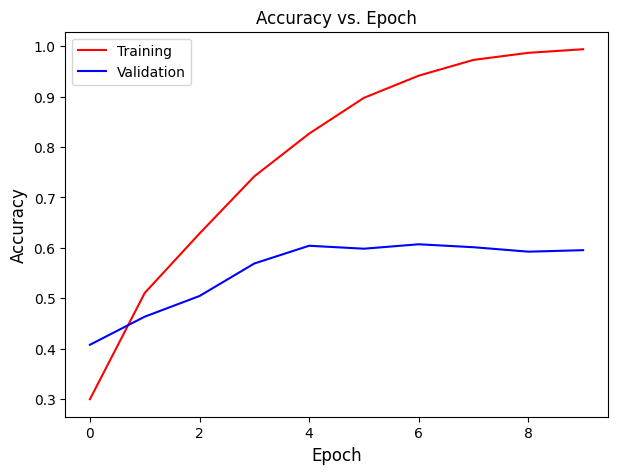

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(range(0, params['epochs']), history['accuracy'], label='Training', color='r')
plt.plot(range(0, params['epochs']), history['val_accuracy'], label='Validation', color='b')

plt.title('Accuracy vs. Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.legend()

plt.show()

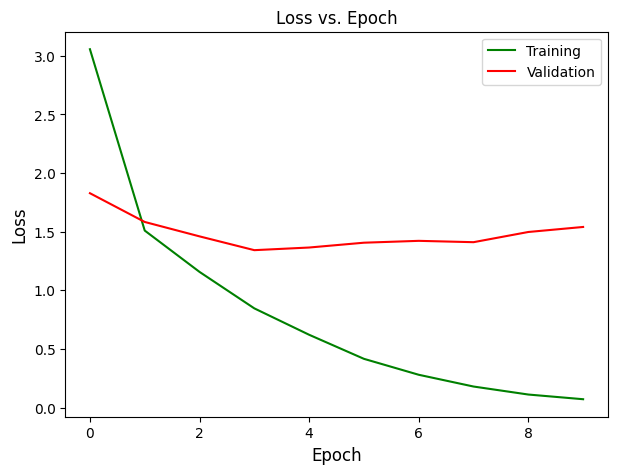

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(range(0, params['epochs']), history['loss'], label='Training', color='g')
plt.plot(range(0, params['epochs']), history['val_loss'], label='Validation', color='r')

plt.title('Loss vs. Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.legend()

plt.show()

- Here we see the problem of overfitting
- These results are better than MLP but far from perfect

### How to reduce overfitting?
There are broadly two ways in which we can reduce overfitting -
1. Modifications in Model Pipeline: Improving Network Configuration to solve over-parametrization
2. Modifications in Data Pipeline: Augmenting Dataset to increase the number of samples

#### Modification 1:

In [ ]:
def model1(height=128, width=128):
    num_classes = 10
    hidden_size = 256

    model = keras.Sequential(
        name="model1",
        layers=[

            layers.Conv2D(filters=16, kernel_size=3,  activation='relu', input_shape=(height, width, 3)),
            layers.MaxPooling2D(),

            layers.Conv2D(filters=32, kernel_size=3,  activation='relu'),
            layers.MaxPooling2D(),

            layers.Conv2D(filters=64, kernel_size=3, activation='relu'),
            layers.MaxPooling2D(),

            layers.Conv2D(filters=128, kernel_size=3,  activation='relu'),
            layers.MaxPooling2D(),

            layers.Conv2D(filters=256, kernel_size=3, activation='relu'),
            layers.GlobalAveragePooling2D(),

            layers.Dense(units=hidden_size, activation='relu'),
            layers.Dense(units=num_classes, activation='softmax')
        ]
    )
    return model

In [ ]:
model = model1()

In [ ]:
model.summary()

Model: "model1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 460,970 (1.76 MB)

 Trainable params: 460,970 (1.76 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
ModelCheckpoint = keras.callbacks.ModelCheckpoint(filepath='tf_model.weights.h5', save_weights_only=True,
                                                  monitor='val_accuracy', mode='max', save_best_only=True),

In [ ]:
model_fit = model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=[ModelCheckpoint])

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 16s 111ms/step - accuracy: 0.2558 - loss: 2.1448 - val_accuracy: 0.3021 - val_loss: 2.0257
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.3464 - loss: 1.9452 - val_accuracy: 0.3724 - val_loss: 1.8426
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.4096 - loss: 1.7435 - val_accuracy: 0.4282 - val_loss: 1.7031
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - accuracy: 0.4591 - loss: 1.5623 - val_accuracy: 0.4809 - val_loss: 1.4773
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.5163 - loss: 1.3689 - val_accuracy: 0.5396 - val_loss: 1.3145
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - accuracy: 0.5723 - loss: 1.2382 - val_accuracy: 0.5396 - val_loss: 1.4251
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - accuracy: 0.5937 - loss: 1.1801 - val_accuracy: 0.5806 - val_loss: 1.2466
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - accuracy: 0.6410 - loss: 1.0488 - val_accuracy: 0.6305

In [ ]:
def acc_plot(model):
    params_cnn = model.params
    history_cnn = model.history

    plt.plot(range(0,params_cnn['epochs']), history_cnn['accuracy'], label='Training', color='r')
    plt.plot(range(0,params_cnn['epochs']), history_cnn['val_accuracy'], label='Validation', color='b')
    plt.title('Model1 Accuracy Plot', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.xlabel('Epoch', fontsize=12)
    plt.legend()

    plt.show()

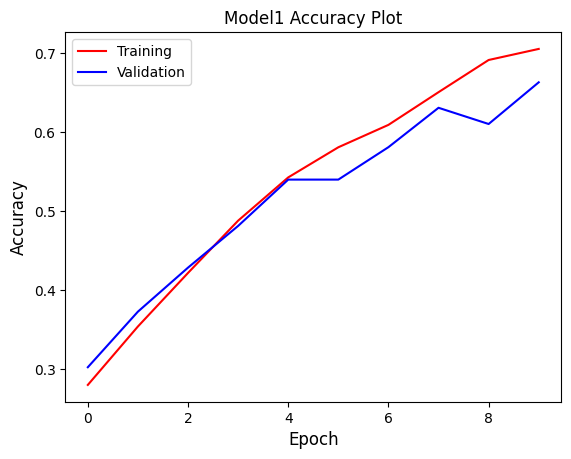

In [ ]:
acc_plot(model_fit)

With just two modifications in the architecture, the model starts performing much better and the problem of overfitting vanish.

#### Increasing the number of epochs as the model starts performing better

In [ ]:
model_fit = model.fit(train_ds, validation_data=val_ds, epochs=30, callbacks=[ModelCheckpoint])

Epoch 1/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - accuracy: 0.7395 - loss: 0.7744 - val_accuracy: 0.6569 - val_loss: 1.0460
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.7436 - loss: 0.7217 - val_accuracy: 0.6481 - val_loss: 1.0817
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - accuracy: 0.7758 - loss: 0.6370 - val_accuracy: 0.6716 - val_loss: 1.0296
Epoch 4/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - accuracy: 0.7969 - loss: 0.5718 - val_accuracy: 0.6305 - val_loss: 1.1681
Epoch 5/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - accuracy: 0.8102 - loss: 0.5464 - val_accuracy: 0.6950 - val_loss: 1.0450
Epoch 6/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.8522 - loss: 0.4203 - val_accuracy: 0.6716 - val_loss: 1.1335
Epoch 7/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - accuracy: 0.8644 - loss: 0.3846 - val_accuracy: 0.6833 - val_loss: 1.2297
Epoch 8/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.8872 - loss: 0.3113 - val_accuracy: 0.7009 - 

In [ ]:
def acc_plot(model):
    params_cnn = model.params
    history_cnn = model.history

    plt.plot(range(0,params_cnn['epochs']), history_cnn['accuracy'], label='Training', color='r')
    plt.plot(range(0,params_cnn['epochs']), history_cnn['val_accuracy'], label='Validation', color='b')
    plt.title('Model1 Accuracy Plot', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.xlabel('Epoch', fontsize=12)
    plt.legend()

    plt.show()

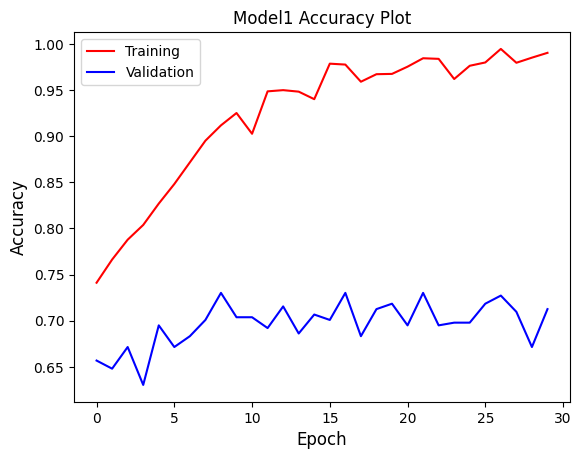

In [ ]:
acc_plot(model_fit)

#### Modification 2:
- Add Batch Normalization after every Conv2D and Dense layers
- Add Dropout after Dense layers

In [ ]:
def model2(height=128, width=128):
    num_classes = 10
    hidden_size = 256

    model = keras.Sequential(
        name="model2",
        layers=[
            layers.Conv2D(filters=16, kernel_size=3, input_shape=(height, width, 3)),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.MaxPooling2D(),

            layers.Conv2D(filters=32, kernel_size=3),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.MaxPooling2D(),

            layers.Conv2D(filters=64, kernel_size=3),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.MaxPooling2D(),

            layers.Conv2D(filters=128, kernel_size=3),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.MaxPooling2D(),

            layers.Conv2D(filters=256, kernel_size=3),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.GlobalAveragePooling2D(),

            layers.Dense(units=hidden_size),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.Dropout(0.5),

            layers.Dense(units=num_classes, activation='softmax')
        ]
    )
    return model

In [ ]:
model = model2()

In [ ]:
model.summary()

Model: "model2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 126, 126, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 61, 61, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,02

 Total params: 463,978 (1.77 MB)

 Trainable params: 462,474 (1.76 MB)

 Non-trainable params: 1,504 (5.88 KB)

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
ModelCheckpoint = keras.callbacks.ModelCheckpoint(filepath='tf_model.weights.h5', save_weights_only=True,
                                                  monitor='val_accuracy', mode='max', save_best_only=True),

In [ ]:
model_fit = model.fit(train_ds, validation_data=val_ds, epochs=30, callbacks=[ModelCheckpoint])

Epoch 1/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 146ms/step - accuracy: 0.2300 - loss: 2.4935 - val_accuracy: 0.2346 - val_loss: 2.3588
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - accuracy: 0.3924 - loss: 1.8533 - val_accuracy: 0.2786 - val_loss: 2.4149
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.5194 - loss: 1.5083 - val_accuracy: 0.3021 - val_loss: 2.4091
Epoch 4/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - accuracy: 0.5654 - loss: 1.2817 - val_accuracy: 0.3314 - val_loss: 2.2767
Epoch 5/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 65ms/step - accuracy: 0.6107 - loss: 1.1175 - val_accuracy: 0.4956 - val_loss: 1.6364
Epoch 6/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - accuracy: 0.6548 - loss: 0.9850 - val_accuracy: 0.5630 - val_loss: 1.3413
Epoch 7/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - accuracy: 0.6987 - loss: 0.8916 - val_accuracy: 0.5279 - val_loss: 1.3451
Epoch 8/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - accuracy: 0.7367 - loss: 0.7674 - val_accuracy: 0.6158 

In [ ]:
def acc_plot(model):
    params_cnn = model.params
    history_cnn = model.history

    plt.plot(range(0,params_cnn['epochs']), history_cnn['accuracy'], label='Training', color='r')
    plt.plot(range(0,params_cnn['epochs']), history_cnn['val_accuracy'], label='Validation', color='b')
    plt.title('Model1 Accuracy Plot', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.xlabel('Epoch', fontsize=12)
    plt.legend()

    plt.show()

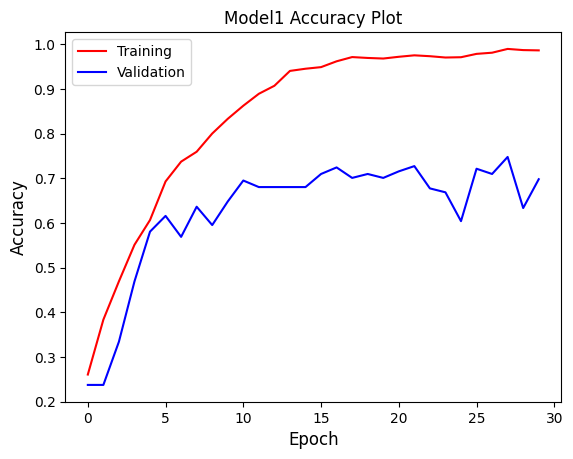

In [ ]:
acc_plot(model_fit)

A lot of fluctuations are observed in the validation accuracy. Therefore, a better alternative is to change the learning rate and let the model train until the loss/accuracy curve flattens out (also called Early Stopping)

#### Modification 3:
- Use a Learning Rate Scheduler
- Early Stopping callback
- Add L2 regularization to Conv2D and Dense layers

In [ ]:
from tensorflow.keras import regularizers

In [ ]:
def model3(height=128, width=128):
    num_classes = 10
    hidden_size = 256

    model = keras.Sequential(
        name="model3",
        layers=[
            layers.Conv2D(filters=16, kernel_size=3, padding="same", input_shape=(height, width, 3),
                            kernel_regularizer=regularizers.l2(1e-3)),
            layers.Activation("relu"),
            layers.BatchNormalization(),
            layers.MaxPooling2D(),

            layers.Conv2D(filters=32, kernel_size=3, padding="same",
                            kernel_regularizer=regularizers.l2(1e-3)),
            layers.Activation("relu"),
            layers.BatchNormalization(),
            layers.MaxPooling2D(),

            layers.Conv2D(filters=64, kernel_size=3, padding="same",
                            kernel_regularizer=regularizers.l2(1e-3)),
            layers.Activation("relu"),
            layers.BatchNormalization(),
            layers.MaxPooling2D(),

            layers.Conv2D(filters=128, kernel_size=3, padding="same",
                            kernel_regularizer=regularizers.l2(1e-3)),
            layers.Activation("relu"),
            layers.BatchNormalization(),
            layers.MaxPooling2D(),

            layers.Conv2D(filters=256, kernel_size=3, padding="same",
                            kernel_regularizer=regularizers.l2(1e-3)),
            layers.Activation("relu"),
            layers.BatchNormalization(),
            layers.GlobalAveragePooling2D(),

            layers.Dense(units=hidden_size, kernel_regularizer=regularizers.l2(1e-3)),
            layers.Activation("relu"),
            layers.BatchNormalization(),
            layers.Dropout(0.5),
            layers.Dense(units=num_classes, activation='softmax')
        ]
    )
    return model

In [ ]:
model = model3()

In [ ]:
model.summary()

Model: "model3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_23 (Activation)      │ (None, 256)            │             

 Total params: 463,978 (1.77 MB)

 Trainable params: 462,474 (1.76 MB)

 Non-trainable params: 1,504 (5.88 KB)

In [ ]:
callbacks = [
              keras.callbacks.ModelCheckpoint(filepath='tf_model.weights.h5', save_weights_only=True, monitor='val_accuracy', mode='max', save_best_only=True),
              keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, min_delta=0.001, mode='min')
            ]

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
model_fit = model.fit(train_ds, validation_data=val_ds, epochs=50,  callbacks=callbacks)

Epoch 1/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 23s 137ms/step - accuracy: 0.1839 - loss: 3.6653 - val_accuracy: 0.2375 - val_loss: 3.0185
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - accuracy: 0.2937 - loss: 2.9771 - val_accuracy: 0.3021 - val_loss: 2.7777
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - accuracy: 0.3734 - loss: 2.6142 - val_accuracy: 0.3314 - val_loss: 2.6571
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - accuracy: 0.4017 - loss: 2.4584 - val_accuracy: 0.3724 - val_loss: 2.8548
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - accuracy: 0.4571 - loss: 2.2290 - val_accuracy: 0.3021 - val_loss: 2.8319
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.4791 - loss: 2.1468 - val_accuracy: 0.3021 - val_loss: 2.7902
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - accuracy: 0.5254 - loss: 1.9981 - val_accuracy: 0.4340 - val_loss: 2.2930
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.5517 - loss: 1.8762 - val_accuracy: 0.4428 

{'verbose': 'auto', 'epochs': 50, 'steps': 96}

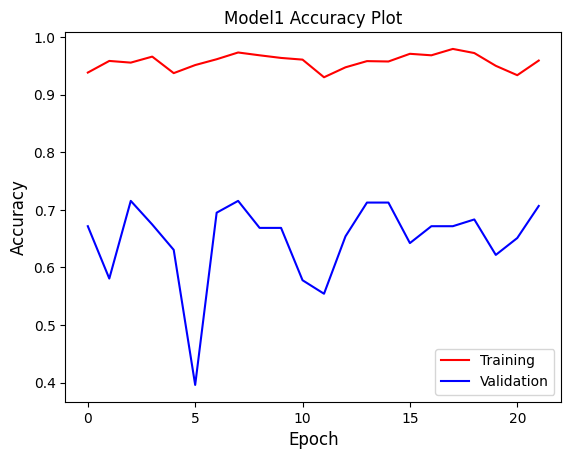

In [ ]:
def acc_plot(model):
    params_cnn = model.params
    history_cnn = model.history

    plt.plot(range(0,22), history_cnn['accuracy'], label='Training', color='r')
    plt.plot(range(0,22), history_cnn['val_accuracy'], label='Validation', color='b')
    plt.title('Model1 Accuracy Plot', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.xlabel('Epoch', fontsize=12)
    plt.legend()

    plt.show()
acc_plot(model_fit)

### **Observation:**
Modifications in the model architecture leads to the better accuracy and loss in both training and validation datasets.

#### 2. Modifications in Data Pipeline:

#### Modification 5:
- Data Augmentation

In [ ]:
height, width = 156, 156
target_height, target_width = 128, 128

In [ ]:
data_preprocess = keras.Sequential(
                        name="data_augmentation",
                        layers=[
                            layers.Resizing(height, width),                 # Shape Preprocessing
                            layers.RandomCrop(target_height, target_width), # Then randomly crop 128,128 region
                            layers.Rescaling(1.0/255),                      # Value Preprocessing
                        ]
                  )

train_ds = train_data.map(lambda x, y: (data_preprocess(x), y))
val_ds = val_data.map(lambda x, y: (data_preprocess(x), y))
test_ds = test_data.map(lambda x, y: (data_preprocess(x), y))

In [ ]:
model = model3()

In [ ]:
model.summary()

Model: "model3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 256)            │             

 Total params: 463,978 (1.77 MB)

 Trainable params: 462,474 (1.76 MB)

 Non-trainable params: 1,504 (5.88 KB)

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
callbacks = [
              keras.callbacks.ModelCheckpoint(filepath='tf_model.weights.h5', save_weights_only=True, monitor='val_accuracy', mode='max', save_best_only=True),
              keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, min_delta=0.001, mode='min')
            ]

In [ ]:
model_fit = model.fit(train_ds, validation_data=val_ds, epochs=50,  callbacks=callbacks)

Epoch 1/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 22s 135ms/step - accuracy: 0.1793 - loss: 3.6986 - val_accuracy: 0.2375 - val_loss: 3.3743
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.3104 - loss: 2.8680 - val_accuracy: 0.2375 - val_loss: 3.3762
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.3639 - loss: 2.7076 - val_accuracy: 0.3050 - val_loss: 3.1938
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.4129 - loss: 2.4406 - val_accuracy: 0.3578 - val_loss: 2.5796
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.4262 - loss: 2.3345 - val_accuracy: 0.4106 - val_loss: 2.3088
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.4944 - loss: 2.0994 - val_accuracy: 0.4076 - val_loss: 2.2535
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.5209 - loss: 2.0382 - val_accuracy: 0.4751 - val_loss: 1.9508
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - accuracy: 0.5426 - loss: 1.9146 - val_accuracy: 0.5132

In [ ]:
def acc_plot(model):
    params_cnn = model.params
    history_cnn = model.history

    plt.plot(range(0,30), history_cnn['accuracy'], label='Training', color='r')
    plt.plot(range(0,30), history_cnn['val_accuracy'], label='Validation', color='b')
    plt.title('Model1 Accuracy Plot', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.xlabel('Epoch', fontsize=12)
    plt.legend()

    plt.show()

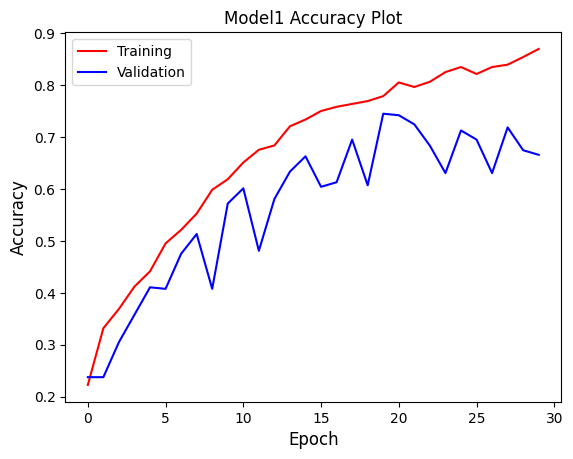

In [ ]:
acc_plot(model_fit)

## **Summary :**
How to reduce overfitting-

- Batch Normalization
- Dropout
- Callbacks
- L2 Regularization
- Data Augmentation Techniques